<a href="https://colab.research.google.com/github/oliviapang/DS_3001_Assignments/blob/main/Assignment_4/4_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 1**

1. Adding a penalty makes it "harder" for the model to use a large number of variables, which keeps the complexity of the model in check and helps avoid models that overfit.
2. Because regularization penalizes complex models, it controls overfitting and attempts to produce models with less variance. By controlling the coefficient size we can control how many or few variables are cut. More variables means less bias and more variance, while fewer variables means more bias and less variance.
3. LASSO sends coefficients to zero/completely removes them, thus creating an optimal model for you. Ridge decreases all coefficients towards zero but never actually removes them. Ridge usually creates better models, but LASSO creates models with more interpretable results.
4. We use standard/z-score scaling. We use this scaling to ensure that each variable is considered equally during regularization. We don't want results that are skewed simply because the units of one variable happen to be several orders of magnitude larger than the units for another.
5. To pick α, a grid of possible values is created, and for each value k-fold cross validation is run. MSE is calculated for each fold and mean/median MSE values are picked for each α. The α correspoding to the lowest mean/median MSE is the optimal value.
6. No, the penalty term is not included. When doing k-fold cross validation, you are trying to decide which penalty value is optimal. Thus, it does not make sense to include that same value in the validation. Additionally, including the penalty value would artificially increase the MSEs for folds with high α values.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
! git clone https://github.com/oliviapang/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 81 (delta 24), reused 5 (delta 5), pack-reused 35 (from 2)
Receiving objects: 100% (81/81), 18.47 MiB | 6.27 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Download complete
Extracting data files...
Data extracted


**Question 2**

In [34]:
# 1
df = pd.read_csv('/content/data/cars_hw.csv')
df['Age'] = 2026 - df['Make_Year']
features = ['Mileage_Run', 'Age']
X = df.loc[:, features]
y = df['Price']

# a
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out()

# b
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [35]:
# 2
from sklearn.linear_model import LinearRegression

y = df['Price']
lmodel = LinearRegression()
lmodel.fit(X_poly, y)
lmodel.coef_

array([ 3.89383823e+01, -5.22484016e-01, -2.71424273e-05, -6.31101083e+00,
       -9.45035192e+00, -4.61648830e-10,  9.40223664e-06,  2.28464871e-01,
       -1.36236292e+02])

The sign for the interaction between Mileage_Run and Age is negative

In [36]:
# 3
%%capture
from sklearn.linear_model import LassoCV, lasso_path
alpha_grid = np.logspace(1,3, 20)
model = LassoCV(cv=10,
                alphas=alpha_grid,
                random_state=100)
model = model.fit(X_poly, y)

index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

Optimal cost hyperparameter: 615.8482110660261


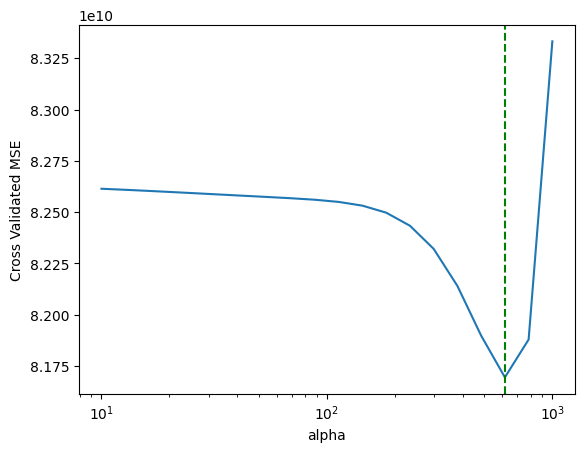

In [37]:
# 4
sns.lineplot( x=model.alphas_, y= np.median(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

In [38]:
# 5
%%capture
from sklearn.linear_model import Lasso

coefs = []
for alpha in alpha_grid: # For each alpha value,
    model = Lasso(alpha=alpha, max_iter=10_000) # Create a lasso model
    model = model.fit(X_poly,y) # Run the regression
    coefs.append(model.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array


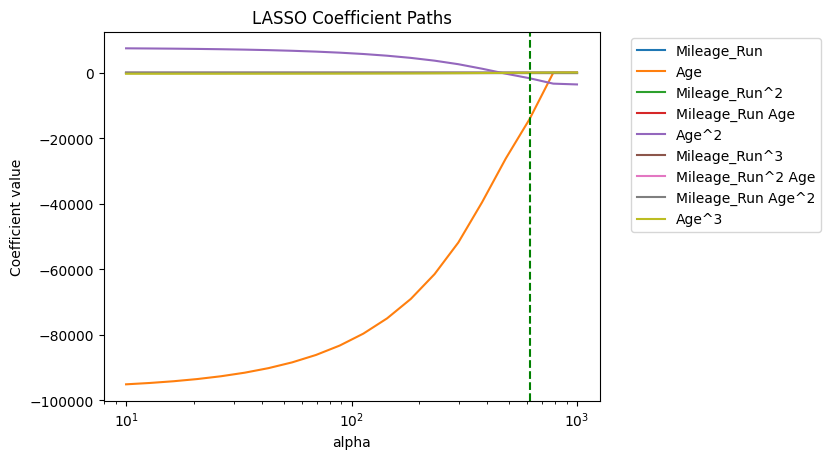

In [39]:
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly_names[i]) # Switched in poly_names
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

6. Age^2 and Age are selected. 7/9 features are set to zero.

In [40]:
# 7
print(lmodel.coef_)
print(coefs[index_star])
poly_names

[ 3.89383823e+01 -5.22484016e-01 -2.71424273e-05 -6.31101083e+00
 -9.45035192e+00 -4.61648830e-10  9.40223664e-06  2.28464871e-01
 -1.36236292e+02]
[ 3.79301788e+01 -9.41728571e+04 -8.29523231e-05 -5.46333674e+00
  7.36958386e+03 -2.96338091e-10  1.17373274e-05  1.75120139e-01
 -2.86751562e+02]


array(['Mileage_Run', 'Age', 'Mileage_Run^2', 'Mileage_Run Age', 'Age^2',
       'Mileage_Run^3', 'Mileage_Run^2 Age', 'Mileage_Run Age^2', 'Age^3'],
      dtype=object)

7. The coefficients for Age, Mileage_Run^2, Mileage_Run^3, and Age^3 all increase in magnitude from the linear model to LASSO. The coefficient for Mileage_Run^3 changes from negative to positive.


**Question 3**

In [41]:
# 1
df = pd.read_csv('/content/data/heart_failure_clinical_records_dataset.csv')
num_features = ['age', 'ejection_fraction', 'serum_creatinine']
X_num = df.loc[:, num_features]
num_poly = PolynomialFeatures(degree = 3, include_bias=False)
X_num_poly = num_poly.fit_transform(X_num)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_poly)
num_poly_names = num_poly.get_feature_names_out()
num_df = pd.DataFrame(X_num_scaled, columns = num_poly_names)

cat_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
cat_poly = PolynomialFeatures(interaction_only = True, include_bias = False)
X_cat = df.loc[:, cat_features]
X_cat_poly = cat_poly.fit_transform(X_cat)
cat_poly_names = cat_poly.get_feature_names_out()
cat_df = pd.DataFrame(X_cat_poly, columns = cat_poly_names)

X = pd.concat([num_df, cat_df], axis=1)
X.head()

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia,diabetes,high_blood_pressure,smoking,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [42]:
# 2
y = df['DEATH_EVENT']
lmodel = LinearRegression()
lmodel.fit(X, y)
names = X.columns
lmodel_coefs = pd.DataFrame(lmodel.coef_.reshape(1, -1), columns = names)
lmodel_coefs

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia,diabetes,high_blood_pressure,smoking,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking
0,1.539156,-2.192494,-0.853588,-3.678654,-0.600918,1.841563,3.430976,2.673394,-2.647041,1.993135,...,0.008093,-0.070705,-0.007934,-0.102687,0.026159,-0.027251,0.064908,0.132443,0.156078,0.101455


2. Diabetes has a negative coefficient, which seems to indicate that having diabetes decreases the probability of dying. However, this is not generally the case in real life, as having a chronic condition doesn't increase one's health. The coefficient is likely negative because of underlying trends in the data. When diabetes interacts with other variables such as anaemia, high blood pressure, or smoking the coefficients are positive. This indicates that while having just diabetes might be statistically inconsequential, when it is paired with other factors it increase the likeliness of death.


In [43]:
# 3
%%capture
alpha_grid = np.logspace(-5,5, 30)
model = LassoCV(cv=20, alphas=alpha_grid, random_state=100)
model = model.fit(X, y)

index_star = np.argmin( np.median(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

Optimal cost hyperparameter: 0.012689610031679234


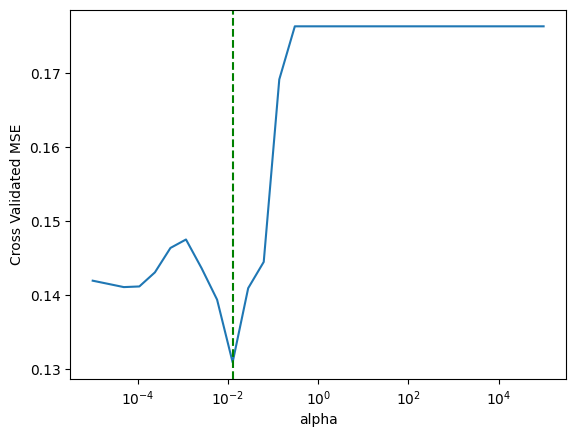

In [44]:
# 4
sns.lineplot( x=model.alphas_, y= np.median(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+01, tolerance: 6.518e

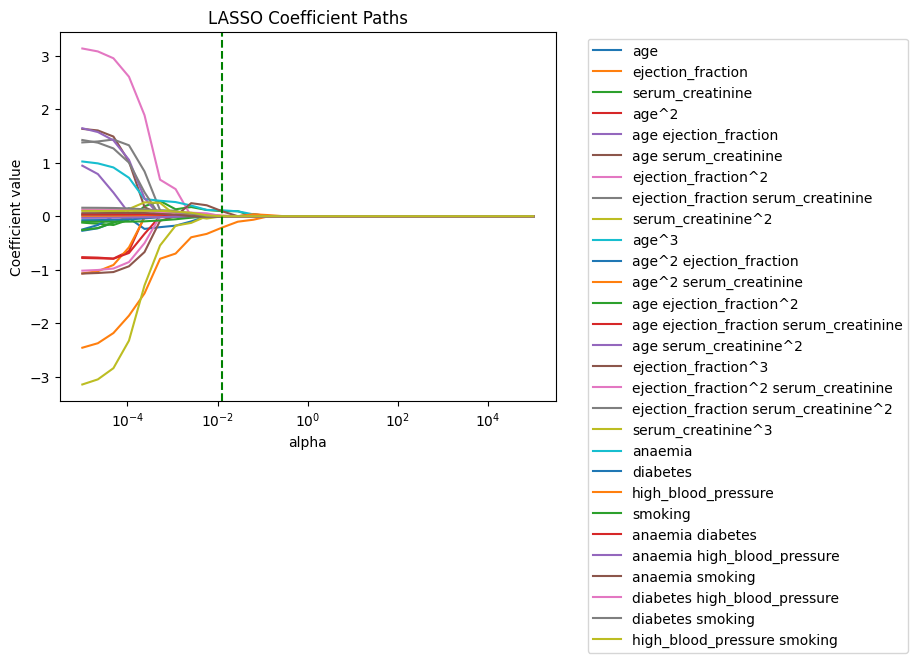

In [45]:
# 5
coefs = []
for alpha in alpha_grid: # For each alpha value,
    model = Lasso(alpha=alpha, max_iter=10_000) # Create a lasso model
    model = model.fit(X,y) # Run the regression
    coefs.append(model.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=names[i]) # Switched in poly_names
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [46]:
# 6
model = Lasso(alpha=0.012689610031679234, max_iter=10_000)
model = model.fit(X,y)
print(lmodel_coefs)
print(pd.DataFrame(model.coef_.reshape(1, -1), columns = names))


        age  ejection_fraction  serum_creatinine     age^2  \
0  1.539156          -2.192494         -0.853588 -3.678654   

   age ejection_fraction  age serum_creatinine  ejection_fraction^2  \
0              -0.600918              1.841563             3.430976   

   ejection_fraction serum_creatinine  serum_creatinine^2     age^3  ...  \
0                            2.673394           -2.647041  1.993135  ...   

    anaemia  diabetes  high_blood_pressure   smoking  anaemia diabetes  \
0  0.008093 -0.070705            -0.007934 -0.102687          0.026159   

   anaemia high_blood_pressure  anaemia smoking  diabetes high_blood_pressure  \
0                    -0.027251         0.064908                      0.132443   

   diabetes smoking  high_blood_pressure smoking  
0          0.156078                     0.101455  

[1 rows x 29 columns]
   age  ejection_fraction  serum_creatinine  age^2  age ejection_fraction  \
0  0.0          -0.210622          0.094559    0.0               

6. The selected features are ejection fraction, serum_creatinine, age^3, high_blood_pressure, and diabetes high_blood_pressure. 24/29 or ~0.8276 of the features are set to zero. The serum_creatinine coefficient increases in magnitude from the linear model to the LASSO model. serum_creatinine and high blood pressure both change signs from linear to LASSO. The signs for the LASSO model make more sense. In the linear model high_blood_pressure is negative, indicating that having high blood pressure lowers the risk of death. However, this is not generally true and is more accurately reflected in the LASSO model, where the coefficient is positive. The linear model seems less accurate because lots of variance is introduced when we expand a 3rd degree polynomial. Doing this creates variables which are highly correlated, and the linear model assigns coefficients to try and reduce error. This leads to a highly variable model, but also one with little bias. The LASSO model penalizes large coefficients and zeros out less useful coefficients, reducing variability. In exchange for the decreased variability, the model becomes more biased.

**Question 4**

Answers in 'question4.pdf'